# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 02: Análise Exploratória de Dados (EDA)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_02_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: data de criação, domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.
- #### <font color='cyan'>Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

O Dataset foi extraido do banco de dados do senso de 1994 dos EUA por Barry Becker, e publicado no repositório em 1996. O dataset compeende dados relacionados às ciências sociais e socioeconômica. O objetivo da base de dados é prever se a renda anualde um individuo ultrapassa U$50.000. O dataset contem 48.842 registros com 14 atributos, incluindo idade, classe de trabalho, final weight, educação, estado civil, ocupação, relacionamento, raça, sexo, ganho e perda de capital, horastrabalhadas por semana e país de origem.

## <font color='green'>Preparação</font>

### <font color='cyan'>Dataset: Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

In [1]:
!pip install pandas ucimlrepo

In [2]:
import pandas as pd

from pprint import pprint
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

In [3]:
pprint(adult.metadata)

{'abstract': 'Predict whether annual income of an individual exceeds $50K/yr '
             'based on census data. Also known as "Census Income" dataset. ',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': None,
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'Extraction was done by Barry Becker from the '
                                '1994 Census database.  A set of reasonably '
                                'clean records was extracted using the '
                                'following conditions: ((AAGE>16) && (AGI>100) '
                                '&& (AFNLWGT>1)&& (HRSWK>0))\n'
                                '\n'
                                'Prediction task is to determine whether a '
                               

In [4]:
adult.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [5]:
X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis='columns')

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


## <font color='green'>**2.1 Conjuntos de Dados**</font>

### <font color='cyan'>Q1: Exiba 10 amostras aleatórias do conjunto de dados.</font>

In [6]:
df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32789,25,NaN,270276,9th,5,Separated,NaN,Not-in-family,White,Female,1055,0,40,United-States,<=50K.
40499,24,Federal-gov,332194,9th,5,Never-married,Adm-clerical,Other-relative,Black,Male,0,0,40,United-States,<=50K.
31343,25,Private,141876,HS-grad,9,Married-spouse-absent,Exec-managerial,Not-in-family,White,Male,0,0,45,United-States,<=50K
37443,24,Private,190015,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K.
44756,24,Self-emp-not-inc,434102,11th,7,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,3,United-States,<=50K.
25666,37,Private,236990,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,3464,0,40,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
18607,60,Private,349898,HS-grad,9,Widowed,Other-service,Not-in-family,White,Female,0,0,44,United-States,<=50K
30187,33,Private,126223,HS-grad,9,Separated,Machine-op-inspct,Unmarried,Black,Female,0,0,40,United-States,<=50K
1204,33,Private,221196,Some-college,10,Married-civ-spouse,Craft-repair,Husband,Black,Male,0,0,40,United-States,<=50K


### <font color='cyan'>Q2: Quantas amostras o conjunto de dados possui?</font>

In [7]:
df.shape[0]

48842

### <font color='cyan'>Q3: Quantas características o conjunto de dados possui?</font>

In [8]:
X.shape[1]

14

### <font color='cyan'>Q4: O conjunto de dados possui características numéricas? Se sim, escreva seu(s) nome(s) e classifique-a(s) como contínua(s) e/ou discreta(s).</font>
- #### <font color='cyan'>Observação: considere que uma caraterística numérica é discreta se possui menos que 50 valores únicos.</font>

In [9]:
num_cols = X.select_dtypes(include='number').columns

for col in num_cols:
    unique_vals = X[col].nunique()
    tipo = "discreta" if unique_vals < 50 else "contínua"
    print(col, "-", tipo, f"({unique_vals} valores únicos)")

age - contínua (74 valores únicos)
fnlwgt - contínua (28523 valores únicos)
education-num - discreta (16 valores únicos)
capital-gain - contínua (123 valores únicos)
capital-loss - contínua (99 valores únicos)
hours-per-week - contínua (96 valores únicos)


### <font color='cyan'>Q5: O conjunto de dados possui características categóricas? Se sim, escreva seu(s) nome(s) e sua(s) quantidade(s) de valores únicos.</font>

In [10]:
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, "-", X[col].nunique())

workclass - 9
education - 16
marital-status - 7
occupation - 15
relationship - 6
race - 5
sex - 2
native-country - 42


## <font color='green'>**2.2 Estatística Descritiva Básica**</font>

### <font color='cyan'> Q6: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

Categoria escolhida: _age_

Matheus Renó Torres

### <font color='cyan'> Q7: Calcule e mostre suas Medidas de Tendência Central (média, mediana e moda).</font>

In [11]:
age_mean = df["age"].mean()
age_median = df["age"].median()
age_mode = df["age"].mode()[0]

print("Média:", age_mean)
print("Mediana:", age_median)
print("Moda:", age_mode)

Média: 38.64358543876172
Mediana: 37.0
Moda: 36


### <font color='cyan'> Q8: Calcule e mostre suas Medidas de Dispersão (mínimo, máximo e amplitude).</font>

In [12]:
age_min = df["age"].min()
age_max = df["age"].max()
age_range = age_max - age_min

print("Mínimo:", age_min)
print("Máximo:", age_max)
print("Amplitude:", age_range)

Mínimo: 17
Máximo: 90
Amplitude: 73


## <font color='green'>**2.3 Análise Univariada**</font>

### <font color='cyan'> Q9: Escolha uma característica categórica do conjunto de dados. Escreva seu nome a seguir.</font>

Categoria escolhida: _education_

Matheus Renó Torres

### <font color='cyan'> Q10: Crie e exiba uma Tabela de Frequência e/ou um Gráfico de Barras para a característica escolhida.</font>

In [13]:
freq_table = df["education"].value_counts()

print(freq_table)

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


### <font color='cyan'> Q11: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

Categoria escolhida: _hours-per-week_

Matheus Renó Torres

### <font color='cyan'> Q13: Crie e exiba um Histograma e/ou uma Estimativa de Densidade por Kernel (KDE) para a característica escolhida.</font>

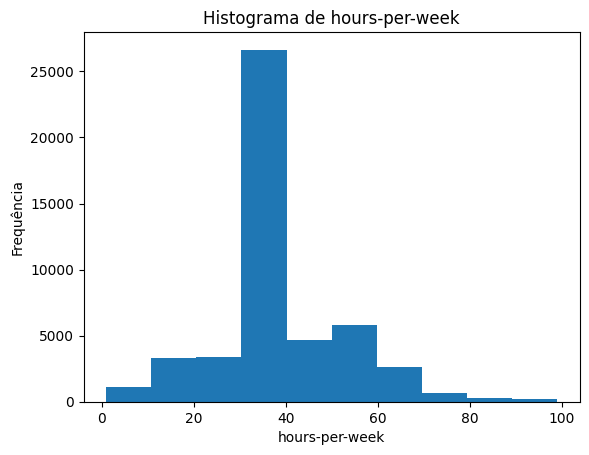

In [14]:
import matplotlib.pyplot as plt

df["hours-per-week"].plot(kind="hist", bins=10)

plt.xlabel("hours-per-week")
plt.ylabel("Frequência")
plt.title("Histograma de hours-per-week")
plt.show()

## <font color='green'>**2.4 Análise Bivariada**</font>

### <font color='cyan'> Q14: Escolha duas características do conjuntos de dados. Escreva seus nome a seguir.</font>

Categorias escolhidas: _education_ e _hours-per-week_

Matheus Renó Torres

### <font color='cyan'> Q15: De acordo com os tipos das características escolhidas, produza pelo menos uma visualização de análise bivariada.</font>

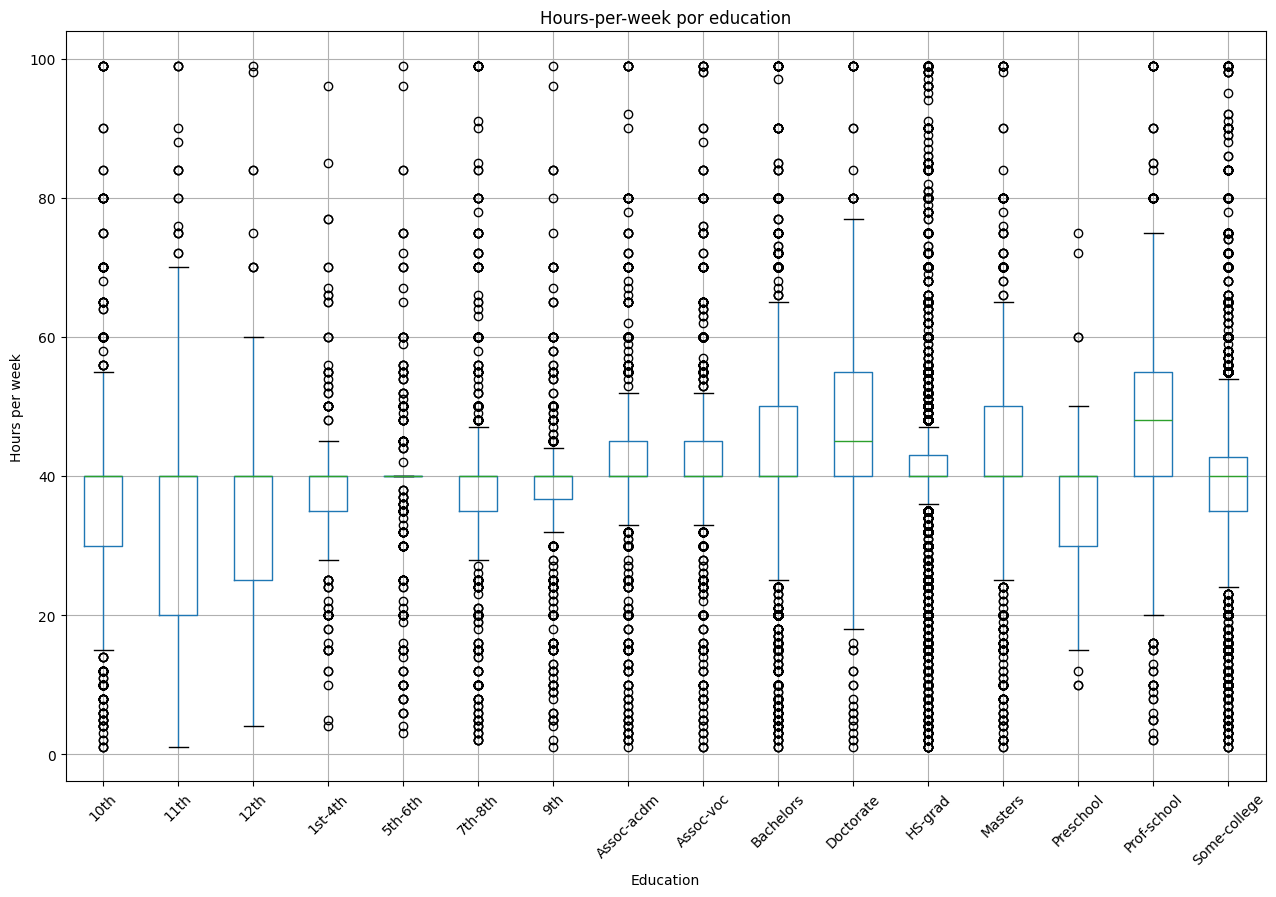

In [15]:
df.boxplot(column="hours-per-week", by="education", rot=45, figsize=(15, 10))

plt.suptitle("")
plt.title("Hours-per-week por education")
plt.xlabel("Education")
plt.ylabel("Hours per week")
plt.show()

## <font color='green'>**2.5 Identificação de Problemas nos Dados**</font>

### <font color='cyan'> Q16: Inspecione o conjuntos de dados para verificar se há:</font>
- #### <font color='cyan'> Dados Ausentes;</font>
- #### <font color='cyan'> Valores Atípicos (via IQR);</font>
- #### <font color='cyan'> Valores Duplicados;</font>
### <font color='cyan'> Reporte sua(s) descoberta(s) a seguir.</font>

In [16]:
# Conta valores ausentes reais em cada coluna
missing_nan = df.isna().sum()

# Conta valores "?" nas colunas categóricas
missing_qmark = df.select_dtypes(include='object').apply(
    lambda s: s.astype(str).str.strip().eq('?').sum()
)

missing_total = missing_nan.add(missing_qmark, fill_value=0).astype(int)
missing_total = missing_total[missing_total > 0].sort_values(ascending=False)
print("Dados ausentes por coluna: ")
print(missing_total)


# Seleciona apenas as colunas numéricas para aplicar o método IQR
num_cols = df.select_dtypes(include='number').columns

iqr_resultados = []

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Conta quantos valores estão abaixo do limite inferior ou acima do superior
    n_outliers = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()

    iqr_resultados.append({
        "variavel": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers": n_outliers
    })

iqr_df = pd.DataFrame(iqr_resultados)
print("\nOutliers por variável numérica:")
print(iqr_df)


duplicados = df.duplicated().sum()
print("\nQuantidade de linhas duplicadas:", duplicados)

Dados ausentes por coluna: 
occupation        2809
workclass         2799
native-country     857
dtype: int64

Outliers por variável numérica:
         variavel        Q1        Q3       IQR  limite_inferior  \
0             age      28.0      48.0      20.0            -2.00   
1          fnlwgt  117550.5  237642.0  120091.5        -62586.75   
2   education-num       9.0      12.0       3.0             4.50   
3    capital-gain       0.0       0.0       0.0             0.00   
4    capital-loss       0.0       0.0       0.0             0.00   
5  hours-per-week      40.0      45.0       5.0            32.50   

   limite_superior  n_outliers  
0            78.00         216  
1        417779.25        1453  
2            16.50        1794  
3             0.00        4035  
4             0.00        2282  
5            52.50       13496  

Quantidade de linhas duplicadas: 29


### <font color='cyan'> Q17: Caso um problema tenha sido encontrado, proponha uma solução para ele.</font>
### <font color='cyan'> Exiba o conjunto de dados antes e depois da solução, enfatizando as mudanças.</font>

In [17]:
df_before = df.copy()

# ANTES

missing_nan_before = df_before.isna().sum()
missing_qmark_before = df_before.select_dtypes(include='object').apply(
    lambda s: s.astype(str).str.strip().eq('?').sum()
)

missing_before = missing_nan_before.add(missing_qmark_before, fill_value=0).astype(int)
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
duplicates_before = df_before.duplicated().sum()

# Conta outliers por IQR
num_cols = df_before.select_dtypes(include='number').columns
outliers_before = {}

for col in num_cols:
    q1 = df_before[col].quantile(0.25)
    q3 = df_before[col].quantile(0.75)

    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    outliers_before[col] = ((df_before[col] < li) | (df_before[col] > ls)).sum()

print("ANTES")
print("Shape:", df_before.shape)
print("\nAusentes:")
print(missing_before)
print("\nDuplicados:", duplicates_before)
print("\nOutliers:")
print(pd.Series(outliers_before))


# LIMPEZA

df_after = df_before.copy()

# Troca "?" por NaN nas colunas categóricas
cat_cols = df_after.select_dtypes(include='object').columns
df_after[cat_cols] = df_after[cat_cols].replace('?', pd.NA)

# Preenche ausentes categóricos com a moda da coluna
for col in cat_cols:
    if df_after[col].isna().sum() > 0:
        moda = df_after[col].mode()[0]
        df_after[col] = df_after[col].fillna(moda)

# Remove linhas duplicadas
df_after = df_after.drop_duplicates()

# Limita outliers numéricos pelos limites do IQR
for col in num_cols:
    q1 = df_after[col].quantile(0.25)
    q3 = df_after[col].quantile(0.75)

    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    df_after[col] = df_after[col].clip(lower=li, upper=ls)


# DEPOIS

missing_nan_after = df_after.isna().sum()
missing_qmark_after = df_after.select_dtypes(include='object').apply(
    lambda s: s.astype(str).str.strip().eq('?').sum()
)

missing_after = missing_nan_after.add(missing_qmark_after, fill_value=0).astype(int)
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

duplicates_after = df_after.duplicated().sum()

outliers_after = {}
for col in num_cols:
    q1 = df_after[col].quantile(0.25)
    q3 = df_after[col].quantile(0.75)

    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    outliers_after[col] = ((df_after[col] < li) | (df_after[col] > ls)).sum()

print("\n\nDEPOIS")
print("Shape:", df_after.shape)
print("\nAusentes:")
print(missing_after)
print("\nDuplicados:", duplicates_after)
print("\nOutliers:")
print(pd.Series(outliers_after))


# COMPARAÇÃO

comparacao = pd.DataFrame({
    "antes": {
        "linhas": df_before.shape[0],
        "colunas": df_before.shape[1],
        "ausentes_total": missing_before.sum(),
        "duplicados": duplicates_before,
        "outliers_total": sum(outliers_before.values())
    },
    "depois": {
        "linhas": df_after.shape[0],
        "colunas": df_after.shape[1],
        "ausentes_total": missing_after.sum(),
        "duplicados": duplicates_after,
        "outliers_total": sum(outliers_after.values())
    }
})

print("\n\nCOMPARAÇÃO GERAL")
print(comparacao)


ANTES
Shape: (48842, 15)

Ausentes:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Duplicados: 29

Outliers:
age                 216
fnlwgt             1453
education-num      1794
capital-gain       4035
capital-loss       2282
hours-per-week    13496
dtype: int64


DEPOIS
Shape: (48813, 15)

Ausentes:
Series([], dtype: int64)

Duplicados: 31

Outliers:
age               0
fnlwgt            0
education-num     0
capital-gain      0
capital-loss      0
hours-per-week    0
dtype: int64


COMPARAÇÃO GERAL
                antes  depois
linhas          48842   48813
colunas            15      15
ausentes_total   6465       0
duplicados         29      31
outliers_total  23276       0


## <font color='green'>**2.6 Correlação Simples**</font>

### <font color='cyan'> Q18: Escolha duas características numéricas do conjuntos de dados. Escreva seus nomes a seguir.</font>

Categorias escolhidas: _age_ e _hours-per-week_

Matheus Renó Torres

### <font color='cyan'> Q19: Calcule e exiba o Coeficiente de Correlação de Pearson ($r$) entre elas.</font>

In [18]:
r = df_after["age"].corr(df_after["hours-per-week"])

print("Coeficiente de Correlação de Pearson (r):", r)

Coeficiente de Correlação de Pearson (r): 0.09308879393472629


### <font color='cyan'> Q20: Interprete o coeficiente de correlação, em termos de sinal e magnitude.</font>

O Coeficiente de Correlação Pearson é r = 0.093, o que é uma correlação positiva muito fraca. Isso sugere que pessoas mais velhas tendem a trabalhar mais horas, mas a relação é pouco intença.